# Classificação de Mensagens: Spam vs. Ham

**Objetivo:** Este notebook tem como propósito desenvolver um pipeline de Machine Learning capaz de classificar mensagens de texto (SMS) como legítimas (*ham*) ou indesejadas (*spam*). 

Utilizaremos técnicas de Processamento de Linguagem Natural (NLP) para limpeza e vetorização dos textos, finalizando com o treinamento e avaliação de um modelo de Árvore de Decisão.

## 1. Importação e Configuração de Ambiente

Nesta etapa inicial, preparamos o ambiente carregando todas as ferramentas essenciais para:
* **Manipulação dos dados:** `pandas` e `numpy`.
* **Visualização:** `matplotlib`.
* **Processamento de Linguagem Natural (NLP):** `nltk` e `spacy` (incluindo o corpus de *stopwords*).
* **Machine Learning:** Módulos do `sklearn` para codificação, vetorização e modelagem.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nltk
import unicodedata
import re
import string
import spacy
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/ester/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Carregamento dos Dados

Iniciamos o fluxo carregando a base de mensagens de texto original. Em seguida, inspecionamos as primeiras linhas para entender a estrutura e o formato inicial do DataFrame.

In [16]:
df = pd.read_csv("data/SMSSpamCollection.csv")
display(df)

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


### 2.1 Análise Exploratória de Dados (EDA)

Antes de tratar o texto, vamos analisar o comportamento da nossa base:
1. **Distribuição das Classes:** Identificar se há desbalanceamento entre as categorias *ham* e *spam*.
2. **Comprimento das Mensagens:** Criar uma variável de contagem de palavras (`Word_count`) e visualizar sua distribuição geométrica para entender o tamanho médio dos textos.

Label
ham     4825
spam     747
Name: count, dtype: int64


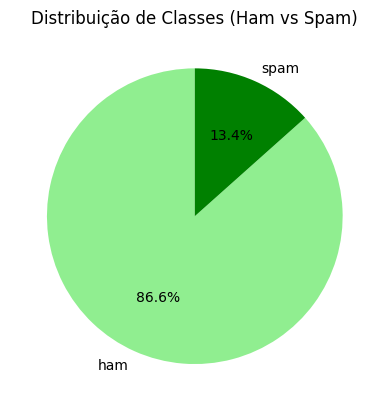

In [42]:
contagem = df['Label'].value_counts()
print(contagem)
contagem.plot(kind='pie', autopct='%1.1f%%', colors=["lightgreen", "green"], title="Distribuição de Classes (Ham vs Spam)", startangle=90, legend=False)
plt.ylabel('')
plt.show()

,Label,Message,Word_count,Message_clean,Word_count_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,jurong point crazy available bugis great world...,12
1,ham,Ok lar... Joking wif u oni...,6,lar joke wif oni,4
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry wkly comp win cup final tkts text r...,15
3,ham,U dun say so early hor... U c already then say...,11,dun early hor,3
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah think go usf life,5
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,30,time try contact pound prize claim easy minute...,9
5568,ham,Will ü b going to esplanade fr home?,8,go esplanade home,3
5569,ham,"Pity, * was in mood for that. So...any other s...",10,pity mood soany suggestion,4
5570,ham,The guy did some bitching but I acted like i'd...,26,guy bitching act like interested buy week give...,9


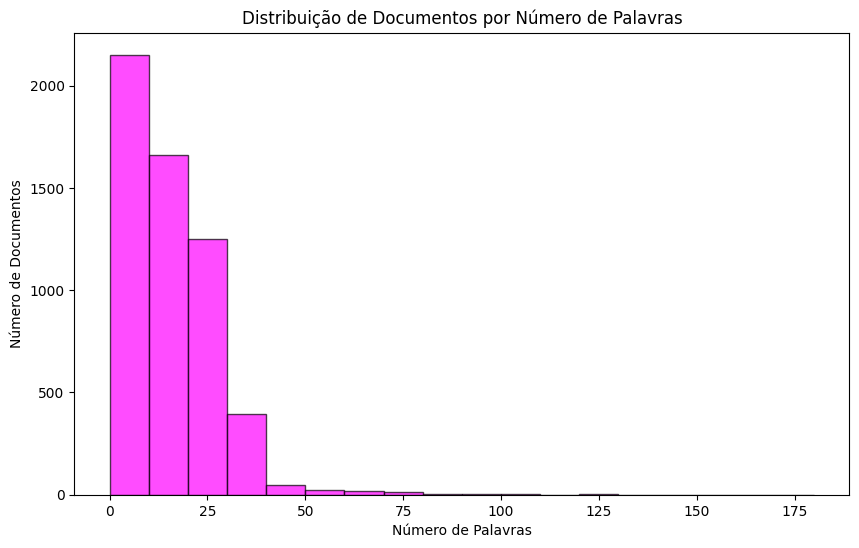

In [43]:
df["Word_count"] = df["Message"].apply(lambda x: len(x.split())) # Número de palavras por documento
# Split divide o texto em palavras usando espaço como separador
display(df)

plt.figure(figsize=(10,6))
plt.hist(df["Word_count"], bins=range(0, df["Word_count"].max() + 10, 10), edgecolor='black', color='magenta', alpha=0.7)

plt.title("Distribuição de Documentos por Número de Palavras")
plt.xlabel("Número de Palavras")
plt.ylabel("Número de Documentos")

plt.show()

In [44]:
df["Word_count"].describe() #Alguns dados
# Count: número de mensagens
# Mean: média de palavras por mensagem
# Std: desvio padrão (o quanto as mensagens variam em relação à média)
# Min: a menor mensagem tem uma palavra
# 25%: 25% das mensagens têm até 7 palavras
# Max: a maior mensagem tem 171 palavras

count    5572.000000
mean       15.597452
std        11.404053
min         1.000000
25%         7.000000
50%        12.000000
75%        23.000000
max       171.000000
Name: Word_count, dtype: float64

## 3. Pipeline de Pré-processamento de Texto

O texto bruto contém muitos ruídos que atrapalham o modelo. Nesta fase, aplicamos um fluxo rigoroso de limpeza:
* **Normalização:** Conversão para letras minúsculas e remoção de acentuação.
* **Limpeza Estrutural:** Exclusão de menções (`@`), *hashtags* (`#`), URLs e sinais de pontuação.
* **Redução de Ruído:** Limitação de letras repetidas em sequência, além da exclusão de números e palavras muito curtas.
* **Lematização e Stopwords:** Utilização do `spacy` para remover palavras sem valor semântico e reduzir os termos à sua raiz morfológica (lema).

In [ ]:
# Passo 1 - Converter para minúsculas, remover acentuação, e stopwords

def processar_etapa1(texto):
    texto = texto.lower() # Coloca tudo em minúsculo
    
    # remove acentuação
    texto = ''.join( # depois de filtrar, junta tudo de novo em uma string normal
        caractere for caractere in unicodedata.normalize('NFD', texto) # Quebra os caracteres acentuados (ex.: ç = c, cedilha)
        if unicodedata.category(caractere) != 'Mn' # Mn = Mark, Nonspacing (acentos, tils, cedilhas...)
    )
    stopwords_en = set(stopwords.words('english')) 
    tokens = texto.split() # quebra em tokens
    tokens = [t for t in tokens if t not in stopwords_en]

    return ' '.join(tokens) # junta novamente em uma string

df["Message_clean"] = df["Message"].apply(processar_etapa1)

In [21]:
# Passo 2 - Remoção de marcações
df["Message_clean"] = df["Message_clean"].apply(lambda x: re.sub(r"[@#][\w@]+", "", x))
# r"[@#]\w+" -> busca o que deve ser removido
# "" -> o que deve ser substituído (nada)

In [ ]:
# Passo 3: remover urls (http e www)

def remover_urls(texto):
    return re.sub(r'(http[s]?://\S+|www\.\S+)', '', texto, flags=re.IGNORECASE)
    # re.sub (padrao, substituo, texto)
    # http\S+ -> pega tudo que comeca com http e segue com qualquer coisa que nao seja espaço
    # www\.\S+ -> pega tudo que comeca com www. seguido por algo que nao seja espaço

df["Message_clean"] = df["Message_clean"].apply(remover_urls)

In [ ]:
# Passo 4 - Reduzir repetições (máximo duas ocorrências)
# Exemplo: boaaaaaaa -> boaa

def reduzir_repeticoes(texto):
    return re.sub(r'(.)\1{2,}', r'\1\1', texto)
    # (.) -> captura qualquer caractere
    # \1 refere-se ao mesmo caractere capturado
    # {2,} -> casa com duas ou mais repetições do mesmo caractere
    # r'\1\1 -> substitui por duas ocorrencias desse caractere

df["Message_clean"] = df["Message_clean"].apply(reduzir_repeticoes)

In [24]:
# Passo 5: remover pontuação

df["Message_clean"] = df["Message_clean"].str.translate(str.maketrans('', '', string.punctuation))

In [25]:
# Etapa 6: remover tokens numéricos

def remover_tokens_numericos(texto):
    tokens = texto.split()
    tokens_sem_numeros = [t for t in tokens if not re.search(r'\d', t)]
    return ' '.join(tokens_sem_numeros)

df["Message_clean"] = df["Message_clean"].apply(remover_tokens_numericos)

In [26]:
# Etapa 7: remover palavras com menos de 3 caracteres

def remover_palavras_curtas(texto):
    tokens = texto.split()
    tokens_sem_palavras_curtas = [t for t in tokens if len(t) >= 3]
    return ' '.join(tokens_sem_palavras_curtas)

df["Message_clean"] = df["Message_clean"].apply(remover_palavras_curtas)

In [27]:
# Lematização

nlp = spacy.load("en_core_web_sm")

def lematizacao(texto):
    doc = nlp(texto)
    tokens_lematizados = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return " ".join(tokens_lematizados)

df["Message_clean"] = df["Message_clean"].apply(lematizacao)

In [28]:
df_clean = df.copy()

,Label,Message,Word_count,Message_clean,Word_count_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,jurong point crazy available bugis great world...,12
1,ham,Ok lar... Joking wif u oni...,6,lar joke wif oni,4
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry wkly comp win cup final tkts text r...,15
3,ham,U dun say so early hor... U c already then say...,11,dun early hor,3
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah think go usf life,5
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,30,time try contact pound prize claim easy minute...,9
5568,ham,Will ü b going to esplanade fr home?,8,go esplanade home,3
5569,ham,"Pity, * was in mood for that. So...any other s...",10,pity mood soany suggestion,4
5570,ham,The guy did some bitching but I acted like i'd...,26,guy bitching act like interested buy week give...,9


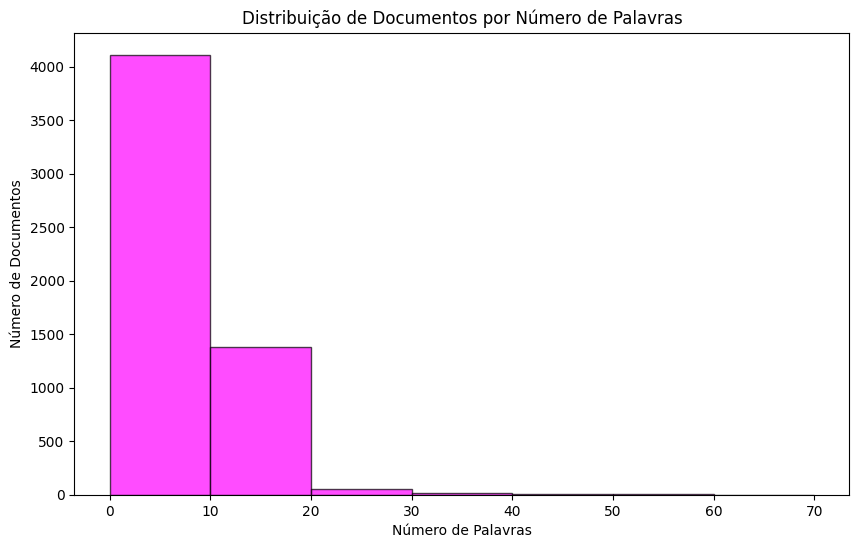

In [29]:
df_clean["Word_count_clean"] = df_clean["Message_clean"].apply(lambda x: len(x.split())) # Número de palavras por documento
display(df_clean)

plt.figure(figsize=(10,6))
plt.hist(df_clean["Word_count_clean"], bins=range(0, df_clean["Word_count_clean"].max() + 10, 10), edgecolor='black', color='magenta', alpha=0.7)

plt.title("Distribuição de Documentos por Número de Palavras")
plt.xlabel("Número de Palavras")
plt.ylabel("Número de Documentos")

plt.show()


### 3.1 Checkpoint: Salvando o Dataset Limpo

Após o processamento do texto, exportamos o resultado final para um arquivo CSV. Isso garante um *checkpoint* seguro dos nossos dados tratados, evitando a necessidade de reprocessar o texto em execuções futuras.

In [ ]:
df_clean.to_csv("data/df_clean.csv", index=False)

## 4. Transformação e Vetorização (TF-IDF)

Com o texto devidamente limpo, precisamos convertê-lo em uma representação matemática compreensível pelo algoritmo:
* **Codificação do Alvo (y):** O `LabelEncoder` transforma as nossas strings de categoria (*ham*/*spam*) em formato binário numérico (**0** e **1**).
* **Vetorização das Features (X):** O `TfidfVectorizer` converte as mensagens em uma matriz numérica baseada na relevância de cada termo (Frequência do Termo - Inverso da Frequência nos Documentos).

In [ ]:
# Representação TF-IDF 

X = df_clean["Message_clean"] # Textos
y = df_clean["Label"]         # Rótulos

# Convertendo rótulos textuais para inteiros (ham = 0, spam = 1)
codificador = LabelEncoder()
y_codificado = codificador.fit_transform(y) 

# Criando o TF-IDF e transformando toda a base de uma vez
vectorizer = TfidfVectorizer()
X_tfidf_completo = vectorizer.fit_transform(X)

print(f"Tamanho do vocabulário gerado: {X_tfidf_completo.shape[1]} palavras.")

Tamanho do vocabulário gerado: 6812 palavras.


## 5. Modelagem: Árvore de Decisão

Nesta etapa final, dividimos nossa matriz vetorizada em conjuntos de treino e teste. Em seguida, instanciamos e treinamos nosso modelo de Árvore de Decisão (`DecisionTreeClassifier`). 

Por fim, avaliamos o desempenho preditivo do modelo analisando sua **Acurácia** geral e o **F1-Score**.

--- Resultado da Árvore de Decisão Simples ---
Acurácia: 0.9605
F1 Score (macro): 0.9153


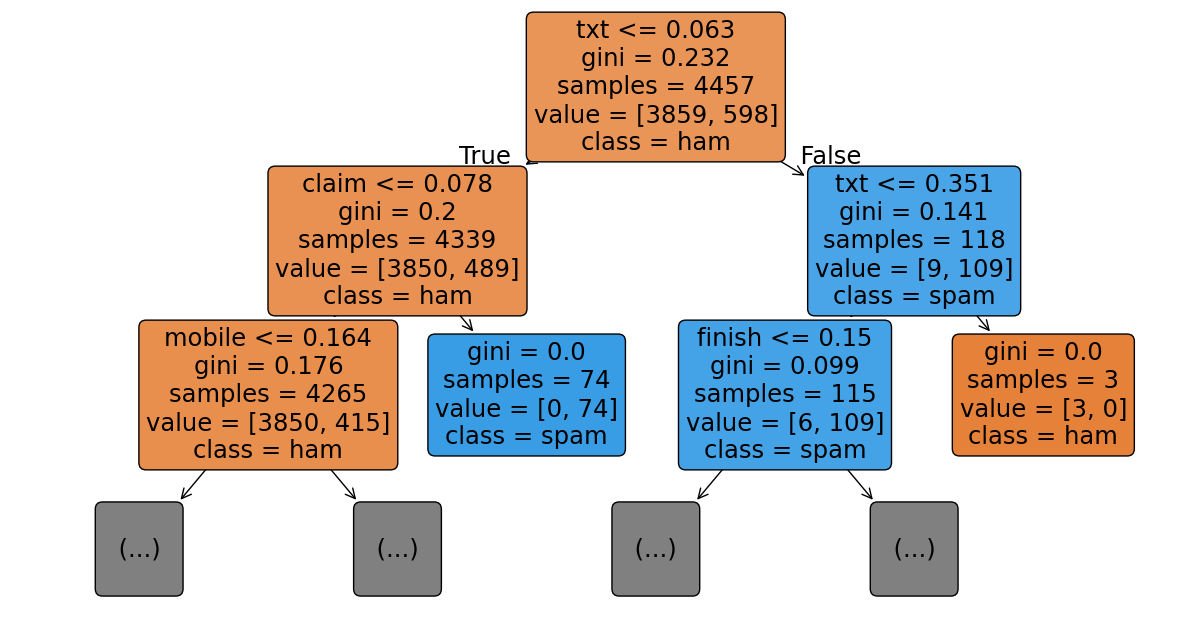

In [ ]:
# Árvore de Decisão

# Dividindo os dados que JÁ passaram pelo TF-IDF (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf_completo, y_codificado, test_size=0.2, random_state=42)

# Inicializa e treina a Árvore
arvore = DecisionTreeClassifier(random_state=42)
arvore.fit(X_train, y_train)

# Faz as previsões no teste
y_pred = arvore.predict(X_test)

# Mostra as métricas
print("--- Resultado da Árvore de Decisão Simples ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

# --- CÓDIGO PARA PLOTAR A ÁRVORE ---
plt.figure(figsize=(15, 8))
tree.plot_tree(arvore, 
               max_depth=2, # Mostra só os 2 primeiros níveis para não virar uma bagunça
               feature_names=vectorizer.get_feature_names_out(), # Coloca os nomes das palavras
               class_names=codificador.classes_, # Mostra se é spam ou ham
               filled=True, # Colore os blocos
               rounded=True)
plt.show()

In [ ]:
# Explicando a árvore exibida
# txt <= 0.063 Critério de divisão: se a frequência da palavra "call" for menor ou igual a 0.063 vai para a esquerda (mais provável ser ham)
# gini = 0.232 Medida de impureza do nó. Quanto menor, mais concentrado em uma única classe.
# samples = 4457 Quantidade de mensagens analisadas nese nó
# value = [3859, 598] 3859 são ham e 598 são spam

### Passo 6: O problema do Vazamento de Dados e o K-Fold
Ao aplicar o TF-IDF em **toda a base** antes de dividir em treino e teste, nosso modelo "decorou" palavras que só existiam nos dados de teste. Isso é chamado de **Vazamento de Dados (Data Leakage)**. 

Para resolver isso e ter uma avaliação mais segura, vamos usar o **K-Fold**. Vamos dividir os dados em 10 pedaços e, em CADA pedaço, o TF-IDF só aprenderá o vocabulário da parte de Treino!

In [ ]:
# K-Fold com o TF-IDF correto

def rodar_kfold(X_textos, y_labels, k=10):
    print(f"--- Iniciando K-Fold ({k} partições) ---")
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    acuracias = []
    f1_scores = []
    
    # Loop passando por cada uma das k partições
    for i, (train_idx, test_idx) in enumerate(skf.split(X_textos, y_labels)):
        
        # Separa os textos de treino e teste ANTES do TF-IDF
        X_fold_train = X_textos.iloc[train_idx]
        X_fold_test = X_textos.iloc[test_idx]
        y_fold_train = y_labels[train_idx]
        y_fold_test = y_labels[test_idx]
        
        # TF-IDF SEM VAZAMENTO: .fit_transform no treino e só .transform no teste
        vec_fold = TfidfVectorizer()
        X_fold_train_tfidf = vec_fold.fit_transform(X_fold_train)
        X_fold_test_tfidf = vec_fold.transform(X_fold_test)
        
        # Treina o Modelo 
        modelo = DecisionTreeClassifier(random_state=42) 
        
        modelo.fit(X_fold_train_tfidf, y_fold_train)
        y_pred_fold = modelo.predict(X_fold_test_tfidf)
        
        # Avalia Acurácia e F1
        acc = accuracy_score(y_fold_test, y_pred_fold)
        f1 = f1_score(y_fold_test, y_pred_fold, average='macro')
        
        acuracias.append(acc)
        f1_scores.append(f1)
        
        print(f"Fold {i+1} -> Acurácia: {acc:.4f} | F1 (macro): {f1:.4f}")
        
    print("\n=== RESULTADOS FINAIS DO K-FOLD ===")
    print(f"Acurácia Média: {np.mean(acuracias):.4f} (± {np.std(acuracias):.4f})")
    print(f"F1 Score (macro) Médio: {np.mean(f1_scores):.4f} (± {np.std(f1_scores):.4f})")

# Executando a função passando os textos puros (X) e os rótulos
rodar_kfold(X, y_codificado, k=10)

--- Iniciando K-Fold (10 partições) ---
Fold 1 -> Acurácia: 0.9677 | F1 (macro): 0.9307
Fold 2 -> Acurácia: 0.9624 | F1 (macro): 0.9177
Fold 3 -> Acurácia: 0.9641 | F1 (macro): 0.9230
Fold 4 -> Acurácia: 0.9605 | F1 (macro): 0.9171
Fold 5 -> Acurácia: 0.9677 | F1 (macro): 0.9299
Fold 6 -> Acurácia: 0.9551 | F1 (macro): 0.9020
Fold 7 -> Acurácia: 0.9551 | F1 (macro): 0.8985
Fold 8 -> Acurácia: 0.9515 | F1 (macro): 0.8930
Fold 9 -> Acurácia: 0.9677 | F1 (macro): 0.9299
Fold 10 -> Acurácia: 0.9569 | F1 (macro): 0.9054

=== RESULTADOS FINAIS DO K-FOLD ===
Acurácia Média: 0.9609 (± 0.0057)
F1 Score (macro) Médio: 0.9147 (± 0.0133)
